In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

raw = yf.download("SPY", start='2025-01-01', end='2026-01-01')
data = raw.droplevel("Ticker", axis=1)
data['daily_return'] = data['Close'].pct_change()
S0 = data['Close'].iloc[-1]
K = 700
r_free = 0.05
T = 1
sigma = data['daily_return'].std() * np.sqrt(252)

d1 = (np.log(S0/K) + (r_free + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
delta = norm.cdf(d1)

print (f'Delta: {delta:.2f}')

[*********************100%***********************]  1 of 1 completed

Delta: 0.58


In [3]:
gamma = norm.pdf(d1) / (S0 * sigma * np.sqrt(T))
print(f'Delta: {delta:.4f}')
print(f'Gamma: {gamma:.6f}')

Delta: 0.5815
Gamma: 0.002942


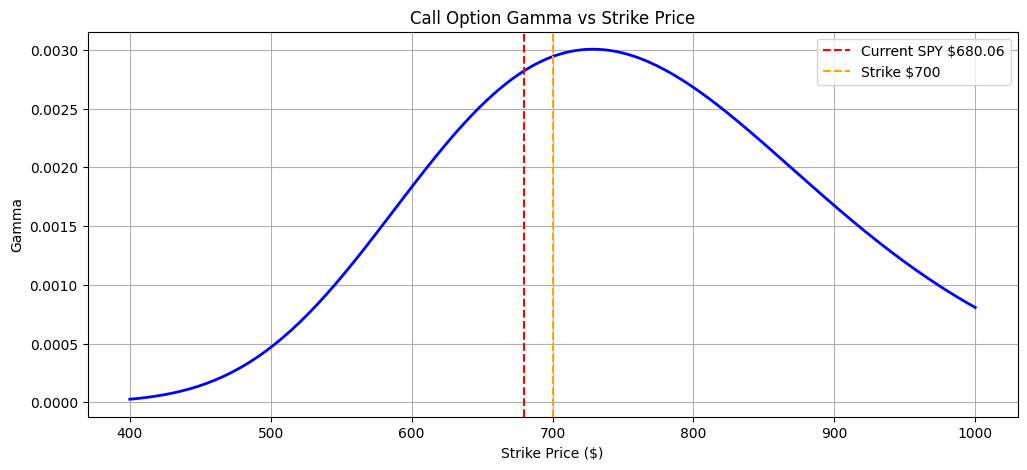

In [4]:
strikes = np.linspace(400, 1000, 200)
gammas = []

for K_loop in strikes:
    d1_loop = (np.log(S0/K_loop) + (r_free + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    gamma_loop = norm.pdf(d1_loop) / (S0 * sigma * np.sqrt(T))
    gammas.append(gamma_loop)

gammas = np.array (gammas)

plt.figure(figsize=(12,5))
plt.plot(strikes, gammas, 'b-', linewidth=2)
plt.axvline(x=S0, color='red', linestyle='--', label=f'Current SPY ${S0:.2f}')
plt.axvline(x=K, color='orange', linestyle='--', label='Strike $700')
plt.title("Call Option Gamma vs Strike Price")
plt.xlabel("Strike Price ($)")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True)
plt.show()

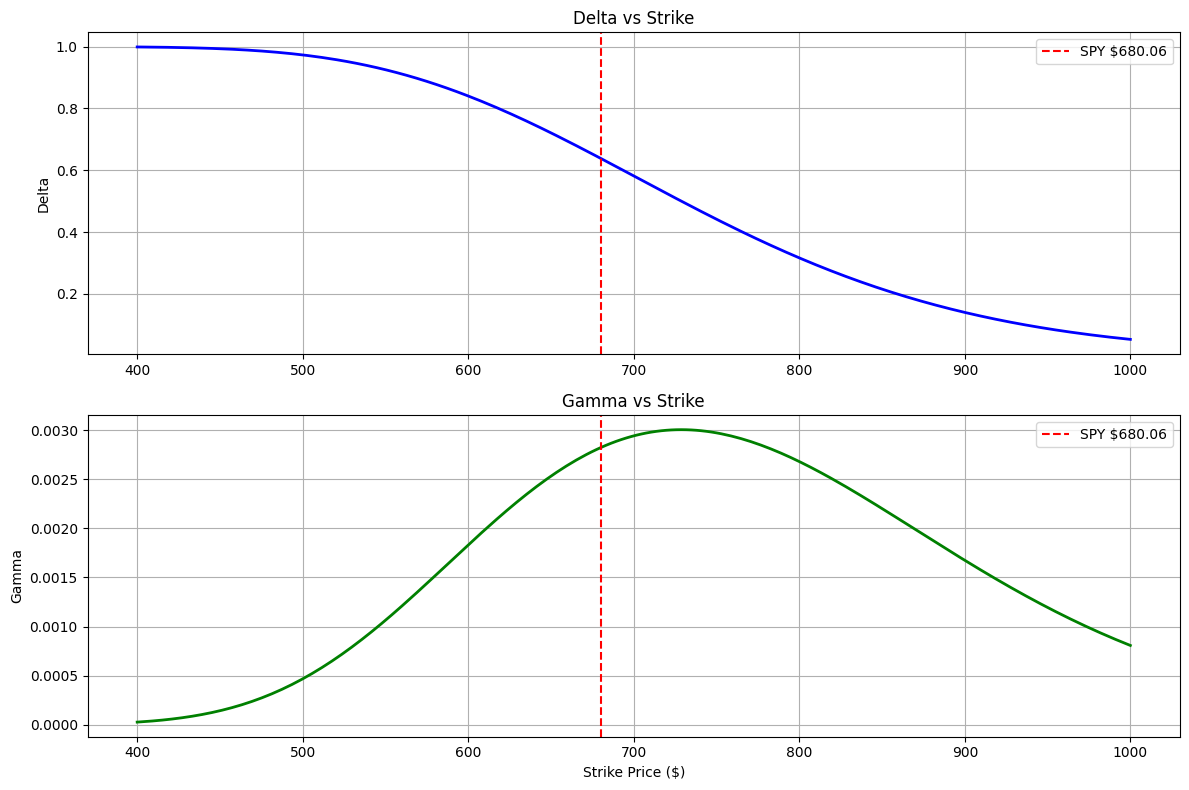

In [7]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))

#Delta
deltas = [norm.cdf((np.log(S0/K_loop) + (r_free + 0.5*sigma**2)*T) / (sigma * np.sqrt(T)))
          for K_loop in strikes]
ax1.plot(strikes, deltas, 'b-', linewidth=2)
ax1.axvline(x=S0, color='red', linestyle='--', label=f'SPY ${S0:.2f}')
ax1.set_title("Delta vs Strike")
ax1.set_ylabel("Delta")
ax1.legend()
ax1.grid(True)

#Gamma
gammas = [(norm.pdf((np.log(S0/K_loop) + (r_free + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))))/ (S0 * sigma * np.sqrt(T))
          for K_loop in strikes]
ax2.plot(strikes, gammas, 'g-', linewidth=2)
ax2.axvline(x=S0, color='red', linestyle='--', label=f'SPY ${S0:.2f}')
ax2.set_title("Gamma vs Strike")
ax2.set_ylabel("Gamma")
ax2.legend()
ax2.grid(True)

plt.xlabel("Strike Price ($)")
plt.tight_layout()
plt.savefig('delta_gamma_comparison.png', dpi=150, bbox_inches='tight')
plt.show()